In [1]:
import pandas as pd
import csv

df = pd.read_csv("pilot5_expanded.csv", delimiter = ";")
df.head()

,id,text,timestamp_tamara,flagged_tamara,comment_tamara,tag_tamara,timestamp_anze,flagged_anze,comment_anze,tag_anze,tag_katja,flagged_katja,comment_katja
0,301,Vsakršno drugačno ravnanje bi po našem preprič...,2023/03/10 14:29:02,NaN,"Opinion known and stated, very negative.",Negative,2023/03/10 14:26:38,NaN,NaN,Negative,Negative,NaN,"Expressed opinion of the speaker, (po našem pr..."
1,302,"Eno od zavajanj, ki so v navedbi priporočil SD...",2023/03/10 14:29:54,True,sarcasm,Negative,2023/03/10 14:28:34,NaN,"No direct opinion, but on negativ side because...",N_Neutral,Negative,NaN,"Implied opinion, but overall very negative, ac..."
2,303,"In nadalje pravi, da slovenski sodniki poleg p...",2023/03/10 14:30:22,NaN,"lacks opiniom,nothing negative",P_Neutral,2023/03/10 14:29:58,NaN,Statment in my opinion is negativ.,Negative,Negative,NaN,Even though the opinion is not clearly express...
3,304,Službena pot oziroma koridorji oziroma neka po...,2023/03/10 14:30:44,NaN,"Nothing negative, lacks opinion",P_Neutral,2023/03/10 14:30:42,NaN,"Stament, nut no direct opinion",P_Neutral,P_Neutral,NaN,"Statement, without underlaying negative connot..."
4,305,"Prosim, če preberete magnetogram in boste ugot...",2023/03/10 14:31:34,NaN,"Opinion clear, negative connotation, but the s...",N_Neutral,2023/03/10 14:32:07,NaN,"Just a statement, but the first part seems lik...",N_Neutral,N_Neutral,NaN,"No expressed opinion, def. neutral, but the to..."


In [25]:
df1 = df.filter(['id', 'text', 'tag_tamara', 'tag_anze', 'tag_katja', 'comment_katja'], axis = 1)
#6-level schema analysis
df1

,id,text,tag_tamara,tag_anze,tag_katja,comment_katja
0,301,Vsakršno drugačno ravnanje bi po našem preprič...,Negative,Negative,Negative,"Expressed opinion of the speaker, (po našem pr..."
1,302,"Eno od zavajanj, ki so v navedbi priporočil SD...",Negative,N_Neutral,Negative,"Implied opinion, but overall very negative, ac..."
2,303,"In nadalje pravi, da slovenski sodniki poleg p...",P_Neutral,Negative,Negative,Even though the opinion is not clearly express...
3,304,Službena pot oziroma koridorji oziroma neka po...,P_Neutral,P_Neutral,P_Neutral,"Statement, without underlaying negative connot..."
4,305,"Prosim, če preberete magnetogram in boste ugot...",N_Neutral,N_Neutral,N_Neutral,"No expressed opinion, def. neutral, but the to..."
...,...,...,...,...,...,...
95,396,"Jaz mislim, da je tako kot so vsi ugotavljali,...",P_Neutral,Positive,P_Neutral,"Explicit opinion, but not strong enough for me..."
96,397,"Ko je morala biti, morala v javnosti pogojena ...",Negative,N_Neutral,Negative,"Implied opinon, but the words ""nedemokratične ..."
97,398,In vi bi zdaj radi še te pol milijarde prenesl...,Negative,Negative,M_Negative,"Though it sounds accusatory, the first part ca..."
98,399,"Za Slovenijo je pomembno, da je njen sistem da...",P_Neutral,P_Neutral,P_Neutral,"Statement, I guess speaker opinion is implied ..."


In [3]:
from sklearn.metrics import cohen_kappa_score
annotator1 = df1['tag_tamara']
annotator2 = df1['tag_anze']
annotator3 = df1['tag_katja']
score1 = cohen_kappa_score(annotator1, annotator2)
score2 = cohen_kappa_score(annotator1, annotator3)
score3 = cohen_kappa_score(annotator2, annotator3)

In [4]:
annotator1 = df1['tag_tamara']
annotator2 = df1['tag_anze']
annotator3 = df1['tag_katja']
# 6-level score Tamara - Anže
cohen_kappa_score(annotator1, annotator2)

0.3061115559113957

In [5]:
annotator1 = df1['tag_tamara']
annotator2 = df1['tag_anze']
annotator3 = df1['tag_katja']
#6-level score Anže - Katja
cohen_kappa_score(annotator2, annotator3)

0.46626522512659097

In [6]:
annotator1 = df1['tag_tamara']
annotator2 = df1['tag_anze']
annotator3 = df1['tag_katja']
#6-level score Tamara - Katja
cohen_kappa_score(annotator1, annotator3)

0.6584340514976353

In [7]:
pilot_score = (score1 + score2 + score3)/3
pilot_score

0.47693694417854066

In [8]:
values_tamara = df1['tag_tamara'].value_counts()
values_tamara

Negative      32
P_Neutral     24
N_Neutral     21
Positive      15
M_Negative     6
M_Positive     2
Name: tag_tamara, dtype: int64

In [9]:
values_anze = df1['tag_anze'].value_counts()
values_anze

Negative     41
P_Neutral    23
Positive     19
N_Neutral    17
Name: tag_anze, dtype: int64

In [10]:
values_katja = df1['tag_katja'].value_counts()
values_katja

Negative      41
P_Neutral     22
Positive      15
N_Neutral     13
M_Negative     8
M_Positive     1
Name: tag_katja, dtype: int64

<AxesSubplot:>

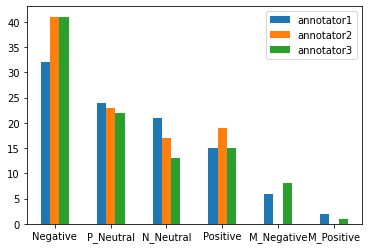

In [11]:
annotator1 = [32, 24, 21, 15, 6, 2]
annotator2 = [41, 23, 17, 19, 0, 0]
annotator3 = [41, 22, 13, 15, 8, 1]
index = ['Negative', 'P_Neutral', 'N_Neutral', 'Positive', 'M_Negative', 'M_Positive']

df2 = pd.DataFrame({'annotator1': annotator1, 'annotator2': annotator2, 'annotator3': annotator3}, index = index)
df2.plot.bar(rot=0)

In [12]:
df1.loc[(df1['tag_tamara'] == 'Negative') | (df1['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df1.loc[(df1['tag_tamara'] == 'Positive') | (df1['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df1.loc[(df1['tag_tamara'] == 'P_Neutral') | (df1['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

In [13]:
df1.loc[(df1['tag_anze'] == 'Negative') | (df1['tag_anze'] == 'M_Negative'), 'sent_anze'] = 'Negative'
df1.loc[(df1['tag_anze'] == 'Positive') | (df1['tag_anze'] == 'M_Positive'), 'sent_anze'] = 'Positive'
df1.loc[(df1['tag_anze'] == 'P_Neutral') | (df1['tag_anze'] == 'N_Neutral'), 'sent_anze'] = 'Neutral'

In [14]:
df1.loc[(df1['tag_katja'] == 'Negative') | (df1['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df1.loc[(df1['tag_katja'] == 'Positive') | (df1['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df1.loc[(df1['tag_katja'] == 'P_Neutral') | (df1['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

In [15]:
df1.filter(['id', 'text', 'sent_tamara', 'sent_anze', 'sent_katja'])

,id,text,sent_tamara,sent_anze,sent_katja
0,301,Vsakršno drugačno ravnanje bi po našem preprič...,Negative,Negative,Negative
1,302,"Eno od zavajanj, ki so v navedbi priporočil SD...",Negative,Neutral,Negative
2,303,"In nadalje pravi, da slovenski sodniki poleg p...",Neutral,Negative,Negative
3,304,Službena pot oziroma koridorji oziroma neka po...,Neutral,Neutral,Neutral
4,305,"Prosim, če preberete magnetogram in boste ugot...",Neutral,Neutral,Neutral
...,...,...,...,...,...
95,396,"Jaz mislim, da je tako kot so vsi ugotavljali,...",Neutral,Positive,Neutral
96,397,"Ko je morala biti, morala v javnosti pogojena ...",Negative,Neutral,Negative
97,398,In vi bi zdaj radi še te pol milijarde prenesl...,Negative,Negative,Negative
98,399,"Za Slovenijo je pomembno, da je njen sistem da...",Neutral,Neutral,Neutral


In [16]:
annotator1 = df1['sent_tamara']
annotator2 = df1['sent_anze']
annotator3 = df1['sent_katja']
cohen_kappa_score(annotator1, annotator2)

0.3353378699161259

In [17]:
annotator1 = df1['sent_tamara']
annotator2 = df1['sent_anze']
annotator3 = df1['sent_katja']
cohen_kappa_score(annotator2, annotator3)

0.5069190392874185

In [18]:
annotator1 = df1['sent_tamara']
annotator2 = df1['sent_anze']
annotator3 = df1['sent_katja']
cohen_kappa_score(annotator1, annotator3)

0.6661897949451598

In [19]:
annotator1 = df1['sent_tamara']
annotator2 = df1['sent_anze']
annotator3 = df1['sent_katja']
three_level_score1 = cohen_kappa_score(annotator1, annotator2)
three_level_score2 = cohen_kappa_score(annotator2, annotator3)
three_level_score3 = cohen_kappa_score(annotator1, annotator3)

three_level_score = (three_level_score1 + three_level_score2 + three_level_score3)/3
three_level_score

0.5028155680495682

In [20]:
sentiment_tamara = df1['sent_tamara'].value_counts()
sentiment_tamara

Neutral     45
Negative    38
Positive    17
Name: sent_tamara, dtype: int64

In [21]:
sentiment_anze = df1['sent_anze'].value_counts()
sentiment_anze

Negative    41
Neutral     40
Positive    19
Name: sent_anze, dtype: int64

In [22]:
sentiment_katja = df1['sent_katja'].value_counts()
sentiment_katja

Negative    49
Neutral     35
Positive    16
Name: sent_katja, dtype: int64

<AxesSubplot:>

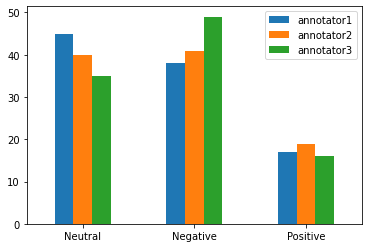

In [24]:
annotator1 = [45, 38, 17]
annotator2 = [40, 41, 19]
annotator3 = [35, 49, 16]
index = ['Neutral', 'Negative', 'Positive']

df4 = pd.DataFrame({'annotator1':annotator1, 'annotator2' : annotator2, 'annotator3':annotator3}, index = index)
df4.plot.bar(rot = 0)